In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("../data/loan_approval_dataset.csv")
df.columns = df.columns.str.strip()

X = df.drop(columns=["loan_id", "loan_status"])
y = df["loan_status"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    X[col] = X[col].str.strip()

y = y.str.strip()

X_encoded = X.copy()
feature_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    feature_encoders[col] = le

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Data prepared successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data prepared successfully.
X_train shape: (3415, 11)
X_test shape: (854, 11)


/var/folders/93/089f0j5140590b91wt26qzwm0000gn/T/ipykernel_18900/2338558402.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [3]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [4]:
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Difference:", train_accuracy - test_accuracy)

Training Accuracy: 1.0
Test Accuracy: 0.9836065573770492
Difference: 0.016393442622950838


In [5]:
print(classification_report(y_test, test_pred, target_names=target_encoder.classes_))

              precision    recall  f1-score   support

    Approved       0.98      0.99      0.99       531
    Rejected       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [6]:
cv_scores = cross_val_score(
    rf_model,
    X_encoded,
    y_encoded,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Average CV accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation scores: [0.9824356  0.9765808  0.98360656 0.97892272 0.98358734]
Average CV accuracy: 0.9810266012503053
Standard deviation: 0.0028067893605824177


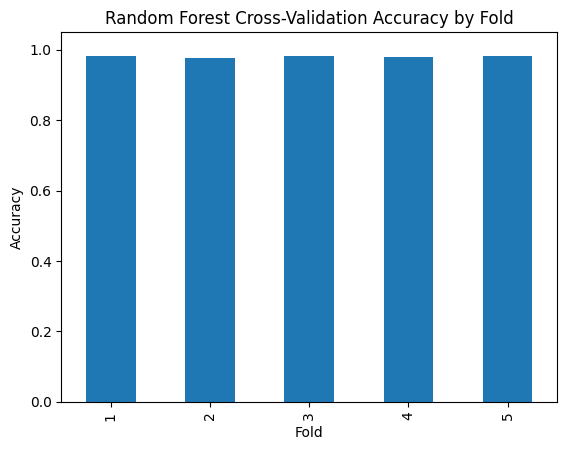

In [7]:
cv_df = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_scores
})

cv_df.plot(x="Fold", y="Accuracy", kind="bar", legend=False)
plt.title("Random Forest Cross-Validation Accuracy by Fold")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.05)
plt.show()

In [8]:
feature_importances = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importances

,Feature,Importance
6,cibil_score,0.800932
5,loan_term,0.064458
4,loan_amount,0.030643
3,income_annum,0.020452
9,luxury_assets_value,0.019373
8,commercial_assets_value,0.018415
7,residential_assets_value,0.017677
10,bank_asset_value,0.015057
0,no_of_dependents,0.007720
2,self_employed,0.002883


In [9]:
X_no_cibil = X_encoded.drop(columns=["cibil_score"])

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_no_cibil,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

rf_no_cibil = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_no_cibil.fit(X_train_nc, y_train_nc)

y_pred_nc = rf_no_cibil.predict(X_test_nc)

accuracy_no_cibil = accuracy_score(y_test_nc, y_pred_nc)

print("Random Forest Accuracy WITHOUT cibil_score:", accuracy_no_cibil)
print(classification_report(y_test_nc, y_pred_nc, target_names=target_encoder.classes_))

Random Forest Accuracy WITHOUT cibil_score: 0.5971896955503513
              precision    recall  f1-score   support

    Approved       0.64      0.81      0.71       531
    Rejected       0.44      0.25      0.32       323

    accuracy                           0.60       854
   macro avg       0.54      0.53      0.52       854
weighted avg       0.56      0.60      0.56       854



In [10]:
comparison = pd.DataFrame({
    "Model Version": ["Random Forest (all features)", "Random Forest (without cibil_score)"],
    "Accuracy": [test_accuracy, accuracy_no_cibil]
})

comparison

,Model Version,Accuracy
0,Random Forest (all features),0.983607
1,Random Forest (without cibil_score),0.597190


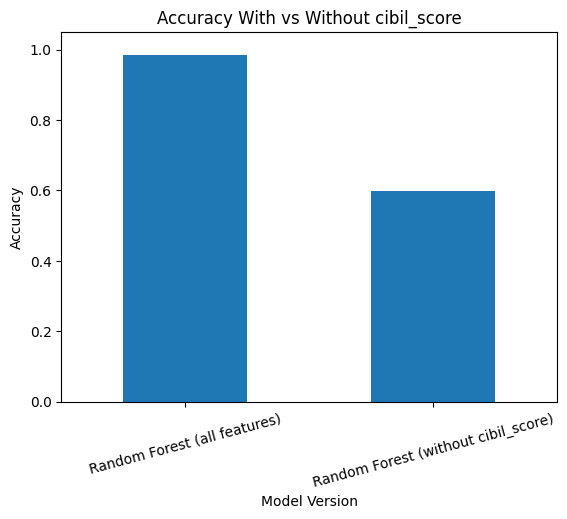

In [11]:
comparison.plot(x="Model Version", y="Accuracy", kind="bar", legend=False)
plt.title("Accuracy With vs Without cibil_score")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.05)
plt.xticks(rotation=15)
plt.show()

In [12]:
joblib.dump(rf_model, "../models/random_forest_model.joblib")
joblib.dump(target_encoder, "../models/target_encoder.joblib")
joblib.dump(feature_encoders, "../models/feature_encoders.joblib")

print("Model and encoders saved successfully.")

Model and encoders saved successfully.


## Step 6 observations

- Checked training vs test accuracy to look for overfitting.
- Ran 5-fold cross-validation to test model stability.
- Reviewed feature importances and confirmed that `cibil_score` is the dominant feature.
- Retrained the model without `cibil_score` to measure dependence on the strongest feature.
- Saved the trained Random Forest model and encoders for future deployment.